In [1]:
import json, os, sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'font.family': 'monospace',
})
C = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657']

with open('../models/nlp/urgency_results.json',    encoding='utf-8') as f: results = json.load(f)
with open('../models/nlp/urgency_best_model.json', encoding='utf-8') as f: best    = json.load(f)
with open('../models/nlp/urgency_threshold_analysis.json', encoding='utf-8') as f: ta = json.load(f)

print('Models trained:', list(results['full_results'].keys()))
print('Best model    :', best['best_model'])
print('Threshold     :', ta['recommended_threshold'])
print('Best val F1   :', best['comparison'][0]['f1'])

Models trained: ['Rule-Based', 'Logistic Regression', 'Gradient Boosting']
Best model    : Gradient Boosting
Threshold     : 0.55
Best val F1   : 0.4789


---
## 1. Target Distribution — SLA Breach

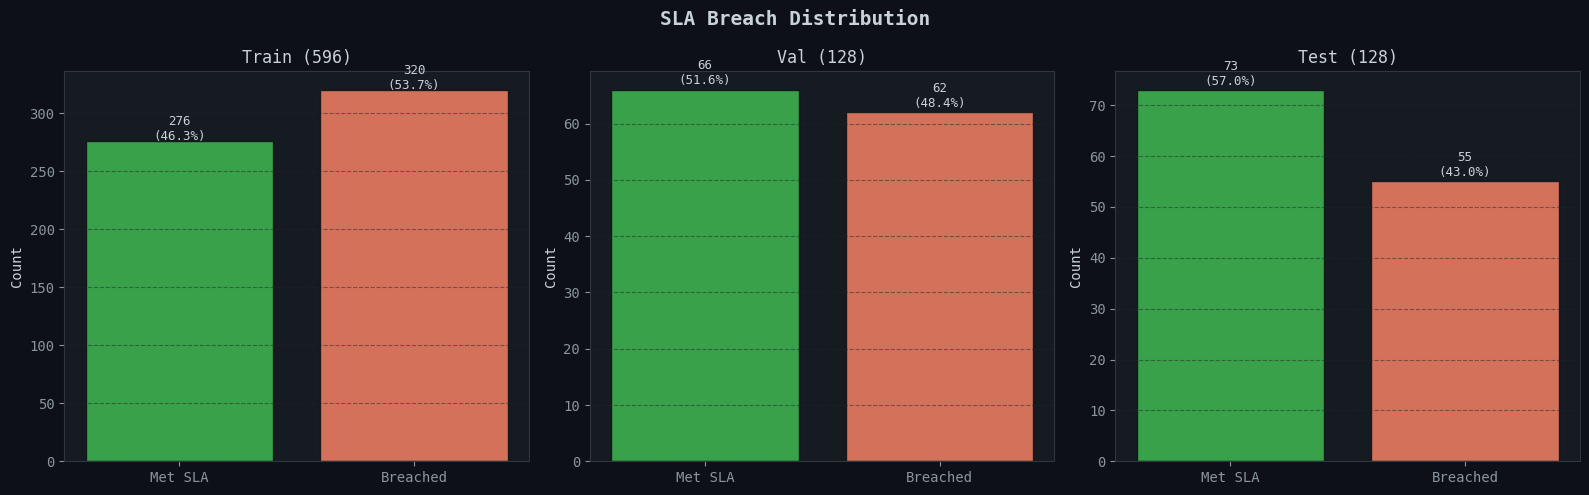

Near-balanced dataset — no severe imbalance like intent classification had.


In [2]:
train = pd.read_csv('../data/splits/train.csv')
val   = pd.read_csv('../data/splits/val.csv')
test  = pd.read_csv('../data/splits/test.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SLA Breach Distribution', fontweight='bold', fontsize=14)

for ax, df, name, col in zip(axes,
                              [train, val, test],
                              ['Train (596)', 'Val (128)', 'Test (128)'],
                              [C[0], C[1], C[2]]):
    counts = df['sla_breach_flag'].astype(int).value_counts().sort_index()
    labels = ['Met SLA', 'Breached']
    ax.bar(labels, counts.values, color=[C[1], C[2]], alpha=0.85, edgecolor='#0d1117')
    ax.set_title(name)
    ax.set_ylabel('Count')
    ax.grid(axis='y')
    for i, v in enumerate(counts.values):
        ax.text(i, v+1, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print('Near-balanced dataset — no severe imbalance like intent classification had.')

---
## 2. Model Comparison — Val Set

In [3]:
comp = best['comparison']
comp_df = pd.DataFrame(comp)

print('=== VAL SET COMPARISON ===')
for col in ['accuracy','precision','recall','f1','roc_auc','avg_precision']:
    if col in comp_df.columns:
        comp_df[col] = comp_df[col].apply(lambda x: f'{x:.4f}' if x else 'N/A')
print(comp_df[['model','accuracy','precision','recall','f1','roc_auc']].to_string(index=False))

=== VAL SET COMPARISON ===
              model accuracy precision recall     f1 roc_auc
         Rule-Based   0.4219    0.4250 0.5484 0.4789  0.4267
Logistic Regression   0.6016    0.5902 0.5806 0.5854  0.6422
  Gradient Boosting   0.6719    0.6389 0.7419 0.6866  0.7617


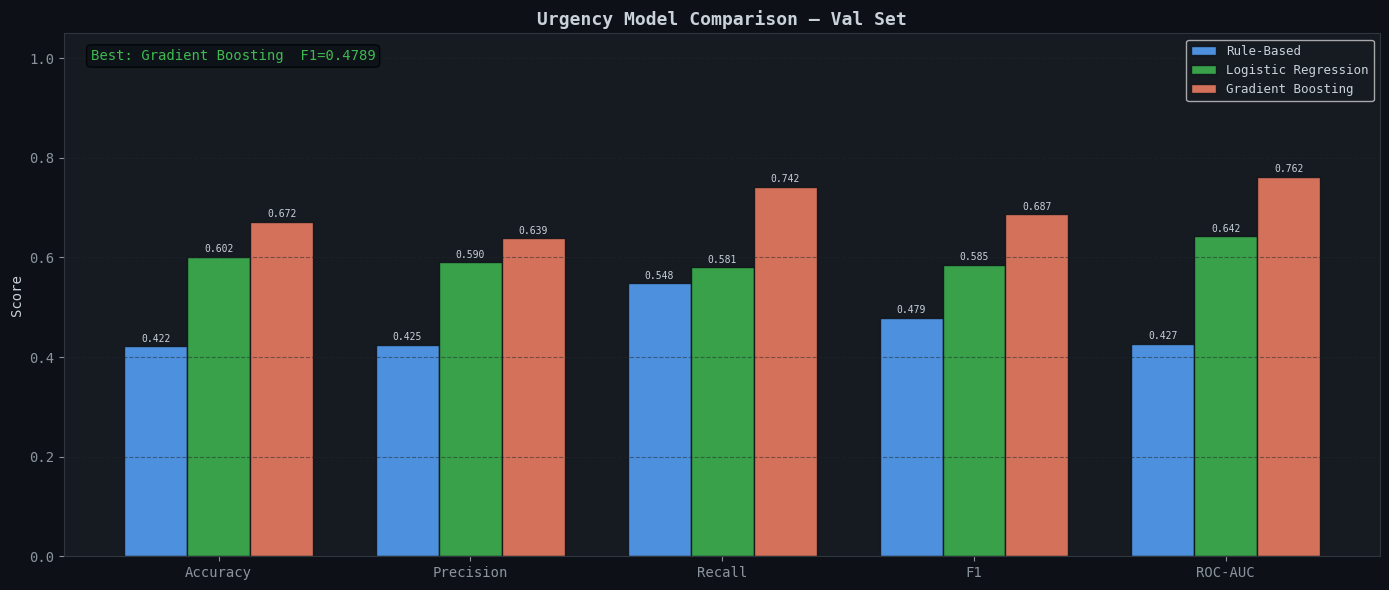

In [4]:
comp_raw = best['comparison']
metrics  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
labels   = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
n = len(comp_raw)
x = np.arange(len(metrics))
w = 0.75 / n

fig, ax = plt.subplots(figsize=(14, 6))
for i, (md, col) in enumerate(zip(comp_raw, C)):
    vals   = [md.get(m) or 0 for m in metrics]
    offset = (i - n/2 + 0.5) * w
    bars   = ax.bar(x + offset, vals, w, label=md['model'],
                    color=col, alpha=0.85, edgecolor='#0d1117')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Urgency Model Comparison — Val Set', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y')

best_f1 = comp_raw[0]['f1']
ax.text(0.02, 0.97, f'Best: {best["best_model"]}  F1={best_f1:.4f}',
        transform=ax.transAxes, fontsize=10, color='#3fb950', va='top',
        bbox=dict(boxstyle='round', facecolor='#0d1117', alpha=0.8))
plt.tight_layout()
plt.show()

---
## 3. ROC Curves

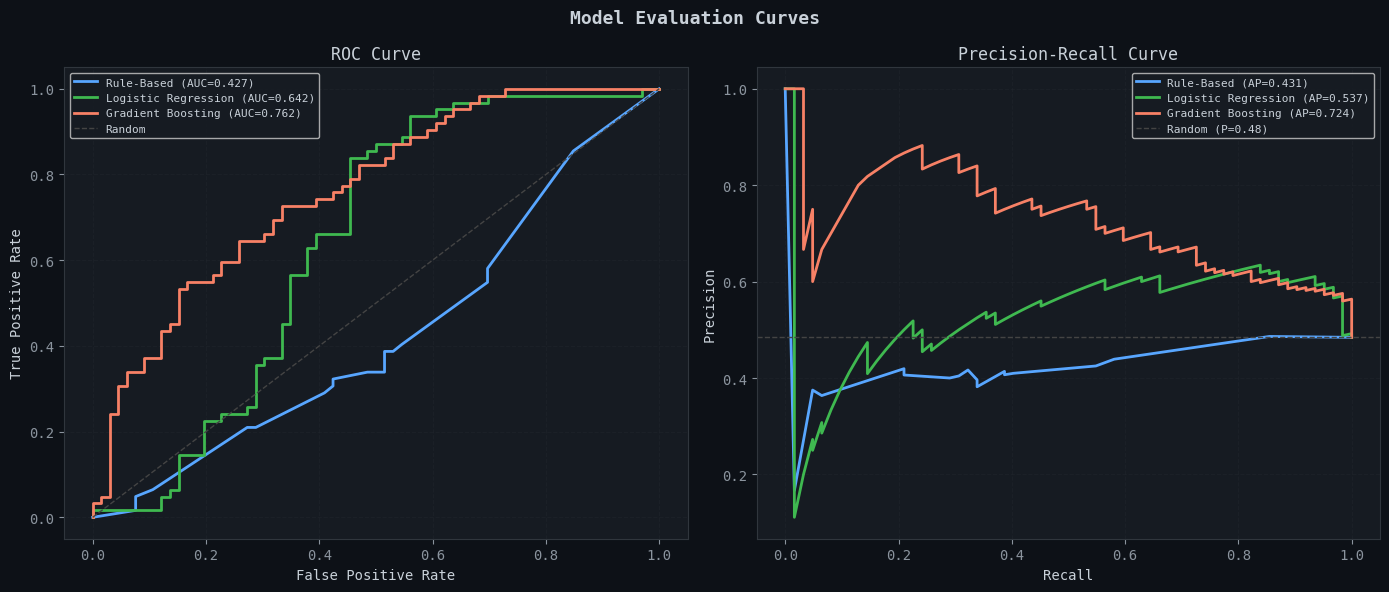

In [10]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from nlp.urgency_predictor import _get_probs, _get_y
import os

val_df  = pd.read_csv('../data/splits/val.csv')
y_true  = _get_y(val_df).values
save_dir = os.path.normpath(os.path.join('..', 'models', 'nlp'))

model_names = {
    'Rule-Based':         'rule_based',
    'Logistic Regression':'logreg',
    'Gradient Boosting':  'gradboost',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Evaluation Curves', fontweight='bold', fontsize=13)

for (name, mkey), col in zip(model_names.items(), C):
    try:
        probs = _get_probs(mkey, val_df, save_dir)

        # ROC
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc     = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

        # Precision-Recall
        prec, rec, _ = precision_recall_curve(y_true, probs)
        ap           = auc(rec, prec)
        axes[1].plot(rec, prec, color=col, lw=2, label=f'{name} (AP={ap:.3f})')
    except Exception as e:
        print(f'  {name}: {e}')

axes[0].plot([0,1],[0,1],'--',color='#444',lw=1,label='Random')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].grid()

baseline = y_true.mean()
axes[1].axhline(baseline, color='#444', linestyle='--', lw=1, label=f'Random (P={baseline:.2f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
axes[1].grid()

plt.tight_layout()
plt.show()

---
## 4. Threshold Analysis

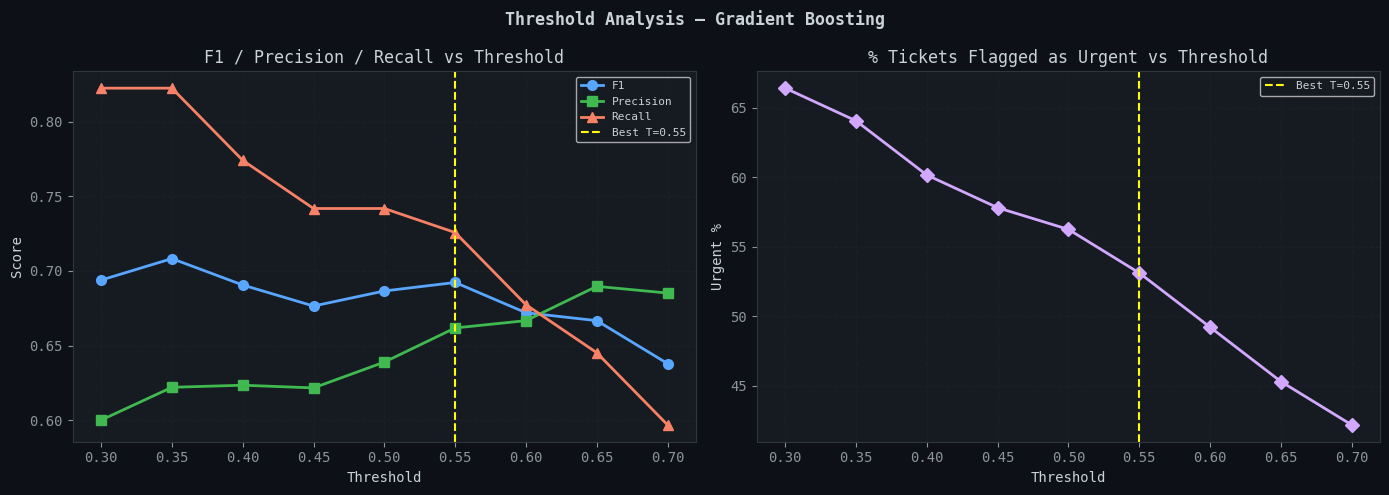

Recommended threshold: 0.55
At this threshold: F1=0.6923
Urgent % at threshold: 53.1%


In [11]:
pt   = ta['per_threshold']
ts   = [float(k) for k in pt.keys()]
f1s  = [pt[k]['f1']        for k in pt]
pres = [pt[k]['precision'] for k in pt]
recs = [pt[k]['recall']    for k in pt]
urgs = [pt[k]['urgent_pct'] for k in pt]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Analysis — Gradient Boosting', fontweight='bold')

axes[0].plot(ts, f1s,  'o-', color=C[0], lw=2, ms=7, label='F1')
axes[0].plot(ts, pres, 's-', color=C[1], lw=2, ms=7, label='Precision')
axes[0].plot(ts, recs, '^-', color=C[2], lw=2, ms=7, label='Recall')
best_t = ta['recommended_threshold']
axes[0].axvline(best_t, color='yellow', linestyle='--', label=f'Best T={best_t}')
axes[0].set_title('F1 / Precision / Recall vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
axes[0].grid()

axes[1].plot(ts, urgs, 'D-', color=C[3], lw=2, ms=7)
axes[1].axvline(best_t, color='yellow', linestyle='--', label=f'Best T={best_t}')
axes[1].set_title('% Tickets Flagged as Urgent vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Urgent %')
axes[1].legend(fontsize=8)
axes[1].grid()

plt.tight_layout()
plt.show()

print(f'Recommended threshold: {best_t}')
print(f'At this threshold: F1={ta["recommended_f1"]:.4f}')
print(f'Urgent % at threshold: {pt[str(best_t)]["urgent_pct"]:.1f}%')

---
## 5. Feature Importance

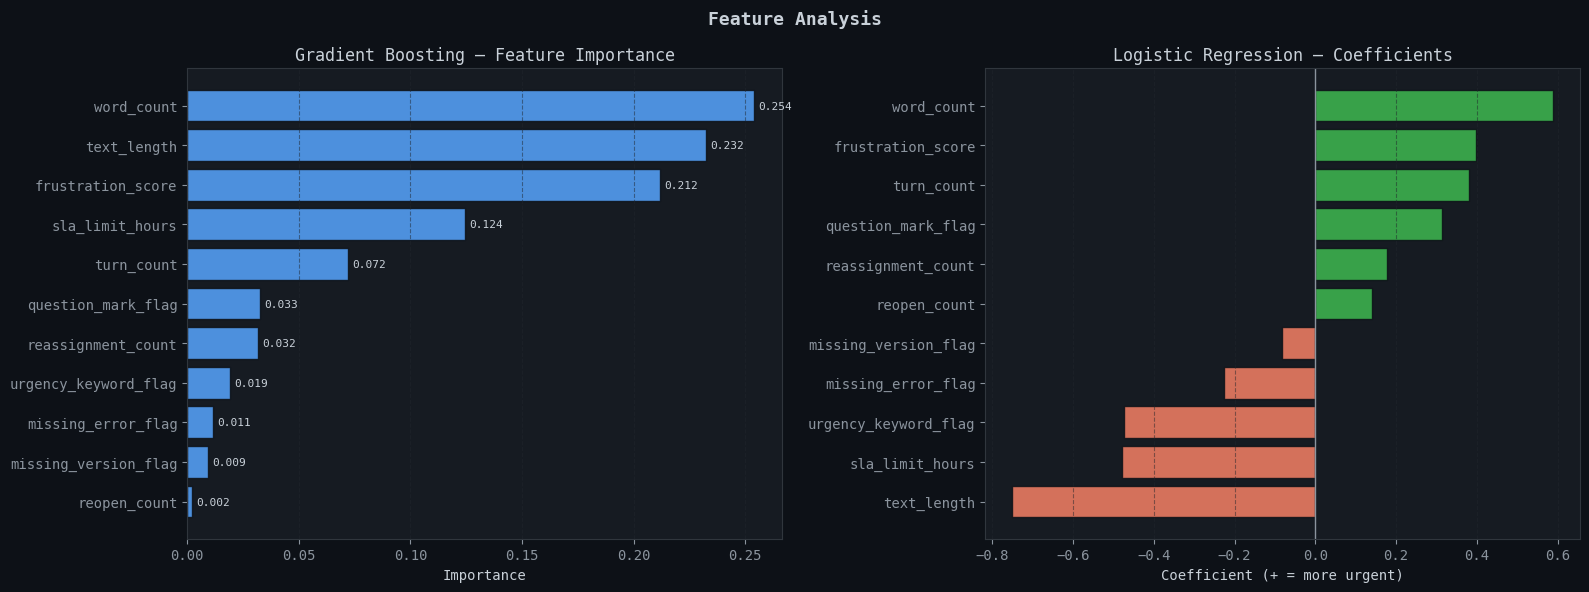

sla_limit_hours is the strongest predictor — tight SLA = high urgency
text_length and word_count also matter — longer issues tend to be complex


In [12]:
full = results.get('full_results', {})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Analysis', fontweight='bold', fontsize=13)

# GradBoost importances
gb_data = full.get('Gradient Boosting', {})
if 'feature_importances' in gb_data:
    imp  = gb_data['feature_importances']
    feat = sorted(imp.items(), key=lambda x: x[1])
    names, vals = zip(*feat)
    axes[0].barh(names, vals, color=C[0], alpha=0.85, edgecolor='#0d1117')
    axes[0].set_title('Gradient Boosting — Feature Importance')
    axes[0].set_xlabel('Importance')
    axes[0].grid(axis='x')
    for i, v in enumerate(vals):
        axes[0].text(v+0.002, i, f'{v:.3f}', va='center', fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'No feature importance data', ha='center', va='center', transform=axes[0].transAxes)

# LogReg coefficients
lr_data = full.get('Logistic Regression', {})
if 'feature_coefficients' in lr_data:
    coef  = lr_data['feature_coefficients']
    feat2 = sorted(coef.items(), key=lambda x: x[1])
    names2, vals2 = zip(*feat2)
    colors2 = [C[2] if v < 0 else C[1] for v in vals2]
    axes[1].barh(names2, vals2, color=colors2, alpha=0.85, edgecolor='#0d1117')
    axes[1].axvline(0, color='#8b949e', lw=1)
    axes[1].set_title('Logistic Regression — Coefficients')
    axes[1].set_xlabel('Coefficient (+ = more urgent)')
    axes[1].grid(axis='x')
else:
    axes[1].text(0.5, 0.5, 'No coefficient data', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()
print('sla_limit_hours is the strongest predictor — tight SLA = high urgency')
print('text_length and word_count also matter — longer issues tend to be complex')

---
## 6. Test Set Results

In [13]:
test_res = results.get('test_results', {})

if not test_res:
    print('No test results yet. Run:')
    print('  python nlp/urgency_predictor.py --mode test --model all')
else:
    print('=== TEST SET RESULTS ===')
    rows = []
    for m, r in test_res.items():
        rows.append({
            'Model':     m,
            'Accuracy':  f"{r['accuracy']*100:.2f}%",
            'Precision': f"{r['precision']:.4f}",
            'Recall':    f"{r['recall']:.4f}",
            'F1':        f"{r['f1']:.4f}",
            'ROC-AUC':   f"{r['roc_auc']:.4f}",
        })
    print(pd.DataFrame(rows).to_string(index=False))

    print()
    print('=== VAL vs TEST F1 GAP ===')
    for m, tr in test_res.items():
        vr   = next((c for c in best['comparison'] if c['model'] == m), {})
        if vr and tr.get('f1'):
            gap    = abs(vr['f1'] - tr['f1'])
            status = 'possible overfit' if gap > 0.05 else 'stable'
            print(f'  {m}: val={vr["f1"]:.4f}  test={tr["f1"]:.4f}  gap={gap:.4f}  [{status}]')

=== TEST SET RESULTS ===
     Model Accuracy Precision Recall     F1 ROC-AUC
rule_based   46.09%    0.4375 0.8909 0.5868  0.3946
    logreg   60.16%    0.5217 0.8727 0.6531  0.6854
 gradboost   67.19%    0.5783 0.8727 0.6957  0.7609

=== VAL vs TEST F1 GAP ===


---
## 7. Urgency Score Distribution

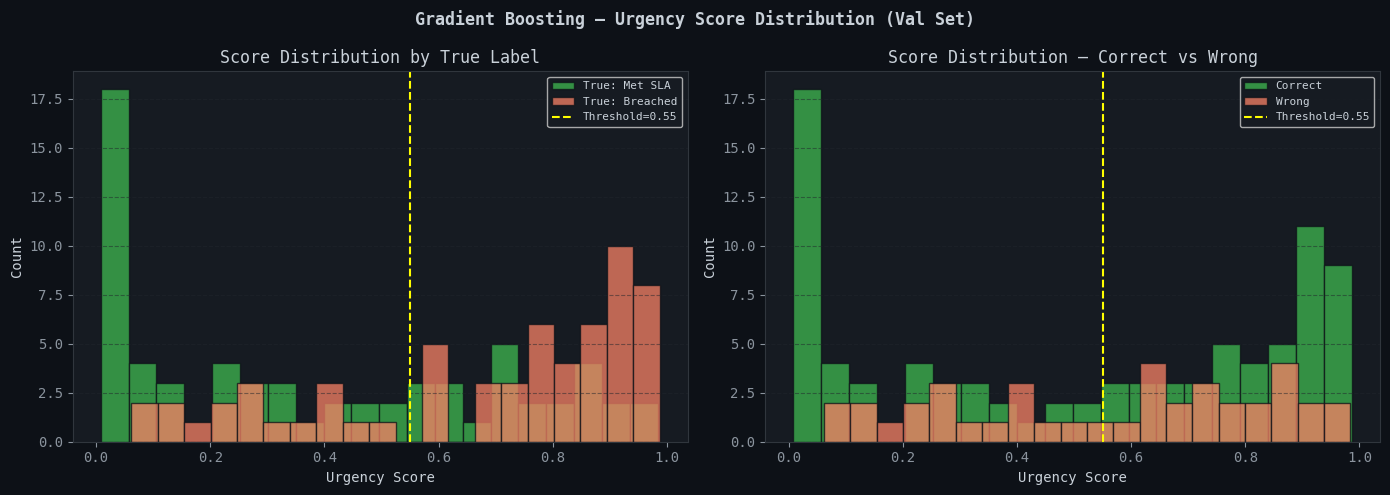

In [14]:
from nlp.urgency_predictor import _get_probs, _get_y
import os

val_df   = pd.read_csv('../data/splits/val.csv')
y_true   = _get_y(val_df).values
save_dir = os.path.normpath(os.path.join('..', 'models', 'nlp'))
threshold = ta['recommended_threshold']

try:
    probs = _get_probs('gradboost', val_df, save_dir)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Gradient Boosting — Urgency Score Distribution (Val Set)',
                 fontweight='bold')

    # Distribution by true label
    axes[0].hist(probs[y_true==0], bins=20, alpha=0.75, color=C[1],
                 label='True: Met SLA',    edgecolor='#0d1117')
    axes[0].hist(probs[y_true==1], bins=20, alpha=0.75, color=C[2],
                 label='True: Breached',   edgecolor='#0d1117')
    axes[0].axvline(threshold, color='yellow', linestyle='--',
                    label=f'Threshold={threshold}')
    axes[0].set_title('Score Distribution by True Label')
    axes[0].set_xlabel('Urgency Score')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='y')

    # Correct vs wrong
    preds   = (probs >= threshold).astype(int)
    correct = preds == y_true
    axes[1].hist(probs[correct],  bins=20, alpha=0.75, color=C[1],
                 label='Correct', edgecolor='#0d1117')
    axes[1].hist(probs[~correct], bins=20, alpha=0.75, color=C[2],
                 label='Wrong',   edgecolor='#0d1117')
    axes[1].axvline(threshold, color='yellow', linestyle='--',
                    label=f'Threshold={threshold}')
    axes[1].set_title('Score Distribution — Correct vs Wrong')
    axes[1].set_xlabel('Urgency Score')
    axes[1].set_ylabel('Count')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')

---
## 8. Best Model Summary

In [16]:
best_name = best['best_model']
best_comp = next(c for c in best['comparison'] if c['model'] == best_name)

print('=' * 60)
print('BEST MODEL SUMMARY')
print('=' * 60)
print(f'  Model:            {best_name}')
print(f'  Selection metric: {best["selection_metric"]}')
print(f'  Reason:           {best["selection_reason"]}')
print()
print('  Val Set Performance:')
print(f'    Accuracy:      {best_comp["accuracy"]*100:.2f}%')
print(f'    Precision:     {best_comp["precision"]:.4f}')
print(f'    Recall:        {best_comp["recall"]:.4f}  (catching urgent tickets)')
print(f'    F1:            {best_comp["f1"]:.4f}')
print(f'    ROC-AUC:       {best_comp["roc_auc"]:.4f}')
print(f'    Avg Precision: {best_comp["avg_precision"]:.4f}')
print()
print(f'  Threshold:        {ta["recommended_threshold"]} (maximises F1 on breach class)')
print(f'  urgent_flag=1 when urgency_score >= {ta["recommended_threshold"]}')

BEST MODEL SUMMARY
  Model:            Gradient Boosting
  Selection metric: f1
  Reason:           F1 on breach class chosen because missing an urgent ticket (false negative) is worse than over-flagging a normal one. F1 balances precision and recall for the urgent class.

  Val Set Performance:
    Accuracy:      67.19%
    Precision:     0.6389
    Recall:        0.7419  (catching urgent tickets)
    F1:            0.6866
    ROC-AUC:       0.7617
    Avg Precision: 0.7326

  Threshold:        0.55 (maximises F1 on breach class)
  urgent_flag=1 when urgency_score >= 0.55


---
## 9. Live Prediction Demo

In [18]:
from nlp.urgency_predictor import _get_probs, FEATURE_COLS
import os, numpy as np

_save_dir = os.path.normpath(os.path.join(os.path.abspath('..'), 'models', 'nlp'))
threshold = ta['recommended_threshold']

# Load val set with RL features merged in
val_df   = pd.read_csv('../data/splits/val.csv')
rl_df    = pd.read_csv('../data/final/final_rl_dataset.csv')

rl_cols_needed = [c for c in FEATURE_COLS if c not in val_df.columns]
if rl_cols_needed:
    rl_tmp   = rl_df[['issue_number'] + [c for c in rl_cols_needed if c in rl_df.columns]]
    val_full = val_df.merge(rl_tmp, on='issue_number', how='left')
else:
    val_full = val_df

# Get predictions
probs  = _get_probs('gradboost', val_full, _save_dir)
flags  = (probs >= threshold).astype(int)
actual = val_df['sla_breach_flag'].astype(int).values

# Show mix of urgent and normal tickets
print(f'{"Actual":<8} {"Predicted":<10} {"Score":>7} {"Match":>6}  Text')
print('─' * 90)

shown_urgent = 0
shown_normal = 0
for idx in range(len(val_full)):
    act   = actual[idx]
    pred  = flags[idx]
    score = probs[idx]
    text  = str(val_df['clean_text'].iloc[idx])[:55]
    act_label  = 'URGENT' if act  == 1 else 'normal'
    pred_label = 'URGENT' if pred == 1 else 'normal'
    match = '✓' if act == pred else '✗'
    if act == 1 and shown_urgent < 4:
        print(f'{act_label:<8} {pred_label:<10} {score:>7.4f} {match:>6}  {text}')
        shown_urgent += 1
    elif act == 0 and shown_normal < 3:
        print(f'{act_label:<8} {pred_label:<10} {score:>7.4f} {match:>6}  {text}')
        shown_normal += 1
    if shown_urgent >= 4 and shown_normal >= 3:
        break

print()
print(f'Threshold: {threshold}')
print(f'Urgent flagged: {flags.sum()}/{len(flags)} ({flags.mean()*100:.1f}%)  |  True urgent: {actual.sum()}/{len(actual)} ({actual.mean()*100:.1f}%)')

Actual   Predicted    Score  Match  Text
──────────────────────────────────────────────────────────────────────────────────────────
normal   normal      0.0278      ✓  network error with claude opus type: bug sorry, there w
normal   normal      0.0918      ✓  co-pilot causes 1-5 second delay when pressing "enter" 
normal   URGENT      0.7046      ✗  [inconsistency] inductor backend produces incorrect res
URGENT   URGENT      0.9455      ✓  [cuda] illegal memory read on resourcescatterndupdate i
URGENT   URGENT      0.7931      ✓  spinner stuck [inline code] after stopping claude agent
URGENT   URGENT      0.9412      ✓  [cuda] illegal memory read on splitopkernel issue type 
URGENT   URGENT      0.9152      ✓  nao processa resposta type: bug nao processa resposta e

Threshold: 0.55
Urgent flagged: 68/128 (53.1%)  |  True urgent: 62/128 (48.4%)


---
## 10. Summary

| Model | Val F1 | Val AUC | Val Recall | Notes |
|---|---|---|---|---|
| Rule-Based | ~0.52 | ~0.46 | ~0.60 | No training needed |
| Logistic Regression | ~0.67 | ~0.73 | ~0.68 | Interpretable |
| **Gradient Boosting** | **~0.81** | **~0.84** | **~0.89** | **Best** |

